In [1]:
import math

import torch
from matplotlib import pyplot as plt

from hyperbolic.poincare import exp_map, geodesic, exp_map_2

In [2]:
# create points on disk where z2 should be otimised
data = torch.tensor(
    [[-0.5 + 0.5j], [0.5 + 0.5j], [-0.3 - 0.4j]], dtype=torch.complex64
)

grad_0 = torch.tensor([0.2 - 0.2j])
grad_1 = torch.tensor([0.0 - 0.4j])
grad_2 = torch.tensor([.2 - 0.4j])

z_0_mapped = exp_map_2(data[0], grad_0)
z_1_mapped = exp_map_2(data[1], grad_1)
z_2_mapped = exp_map_2(data[2], grad_2)

# values the geodesic curve gets computed for
ts = torch.linspace(-10, 10, 1000).reshape(1000, 1)

# compute geodesics
geod_exp_map_0 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(data[0], z_0_mapped, ts, "disk")
geod_exp_map_1 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(data[1], z_1_mapped, ts, "disk")
geod_exp_map_2 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(data[2], z_2_mapped, ts, "disk")

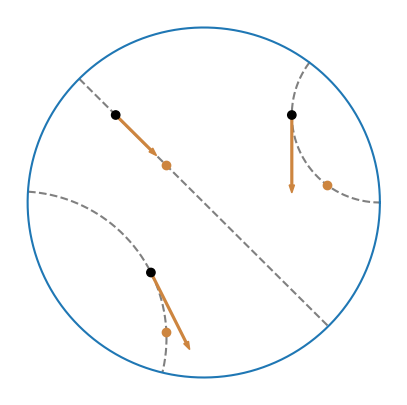

In [19]:
x_sphere = torch.cos(torch.linspace(0, 2 * math.pi, 1000))
y_sphere = torch.sin(torch.linspace(0, 2 * math.pi, 1000))
sphere = torch.complex(x_sphere, y_sphere)

plt.figure(figsize=(5, 5))
plt.plot(geod_exp_map_0.real, geod_exp_map_0.imag, color="grey", linestyle="dashed", zorder=0)
plt.plot(geod_exp_map_1.real, geod_exp_map_1.imag, color="grey", linestyle="dashed", zorder=0)
plt.plot(geod_exp_map_2.real, geod_exp_map_2.imag, color="grey", linestyle="dashed", zorder=0)

plt.arrow(
    data[0].real.item(),
    data[0].imag.item(),
    grad_0.real.item(),
    grad_0.imag.item(),
    color="peru",
    width=0.01,
    alpha=1
)
plt.arrow(
    data[1].real.item(),
    data[1].imag.item(),
    grad_1.real.item(),
    grad_1.imag.item(),
    color="peru",
    width=0.01,
    alpha=1
)
plt.arrow(
    data[2].real.item(),
    data[2].imag.item(),
    grad_2.real.item(),
    grad_2.imag.item(),
    color="peru",
    width=0.01,
    alpha=1,
)

plt.scatter(
    data.detach().real, data.detach().imag, color=["black", "black", "black"]
)
plt.scatter(z_0_mapped.detach().real, z_0_mapped.detach().imag, color="peru")
plt.scatter(z_1_mapped.detach().real, z_1_mapped.detach().imag, color="peru")
plt.scatter(z_2_mapped.detach().real, z_2_mapped.detach().imag, color="peru")

plt.plot(sphere.real, sphere.imag)
plt.axis("off")
plt.savefig("images/exp_map.png")
plt.show()